# CV analysis - 2026-07-15 electropol PPy on 500 um decell tissue (2.5 mV/s)

Cyclic voltammograms (current vs applied potential) for the **palmsense3** and **palmsense4**
runs. Each PalmSens export holds **3 CV scans (cycles)**, sweeping +1 V -> -1 V -> +1 V at
**2.5 mV/s**. Loader is the same UTF-16 / 6-line-header / N-scans-side-by-side parser used in
`6.18.26_misc_experiments/cv_20260618_FORCE_analysis.ipynb`.

- palmsense3: `potentiostat/07.15.26-pyrrole-electropol-FORCE-palmsense3.csv`
- palmsense4: `potentiostat/07.15.26-pyrrole-electropol-FORCE-palmsense4.csv` (noted as the weaker run)

Both are the potentiostat (electrochemistry) side of the electropol-FORCE runs; the scope
force logs live in the parent folder and are not used here.

In [7]:
import io, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

POTEN_DIR = 'potentiostat'
PALMSENSE3 = f'{POTEN_DIR}/07.15.26-pyrrole-electropol-FORCE-palmsense3.csv'
PALMSENSE4 = f'{POTEN_DIR}/07.15.26-pyrrole-electropol-FORCE-palmsense4.csv'
PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']


def load_poten_cv(path):
    """PalmSens CV export: UTF-16, 6-line header, then (V, uA) columns per scan."""
    with open(path, 'rb') as f:
        text = f.read().decode('utf-16').replace('\ufeff', '')
    rows = list(csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))))
    rows = [r for r in rows if r and r[0]]
    nsc = len(rows[0]) // 2
    cols = []
    for s in range(nsc):
        cols += [f'v{s+1}', f'i{s+1}_uA']
    df = pd.DataFrame([[float(x) for x in r[:2*nsc]] for r in rows], columns=cols)
    return df, nsc


def plot_cv(path, title):
    df, n = load_poten_cv(path)
    print(f'{title}: {n} scans, {len(df)} samples/scan')
    fig, axes = plt.subplots(1, n + 1, figsize=(6 * (n + 1), 5.5), squeeze=False)

    ax = axes[0, 0]
    for c in range(n):
        ax.plot(df[f'v{c+1}'], df[f'i{c+1}_uA'], color=PALETTE[c % len(PALETTE)],
                lw=1.4, alpha=0.9, label=f'cycle {c+1}')
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_xlabel('Applied potential (V)')
    ax.set_ylabel('Current (uA)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    ax.set_title('all cycles overlaid', fontsize=10)

    for c in range(n):
        axc = axes[0, c + 1]
        axc.plot(df[f'v{c+1}'], df[f'i{c+1}_uA'], color=PALETTE[c % len(PALETTE)], lw=1.2)
        axc.axhline(0, color='k', lw=0.5, alpha=0.5)
        axc.set_xlabel('Applied potential (V)')
        axc.set_ylabel('Current (uA)')
        axc.grid(True, alpha=0.3)
        axc.set_title(f'cycle {c+1}', fontsize=10)

    fig.suptitle(f'{title} - CV, 2.5 mV/s (+1 V -> -1 V -> +1 V)', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    return df, n

## palmsense3 run

palmsense3 (electropol-FORCE): 3 scans, 8683 samples/scan


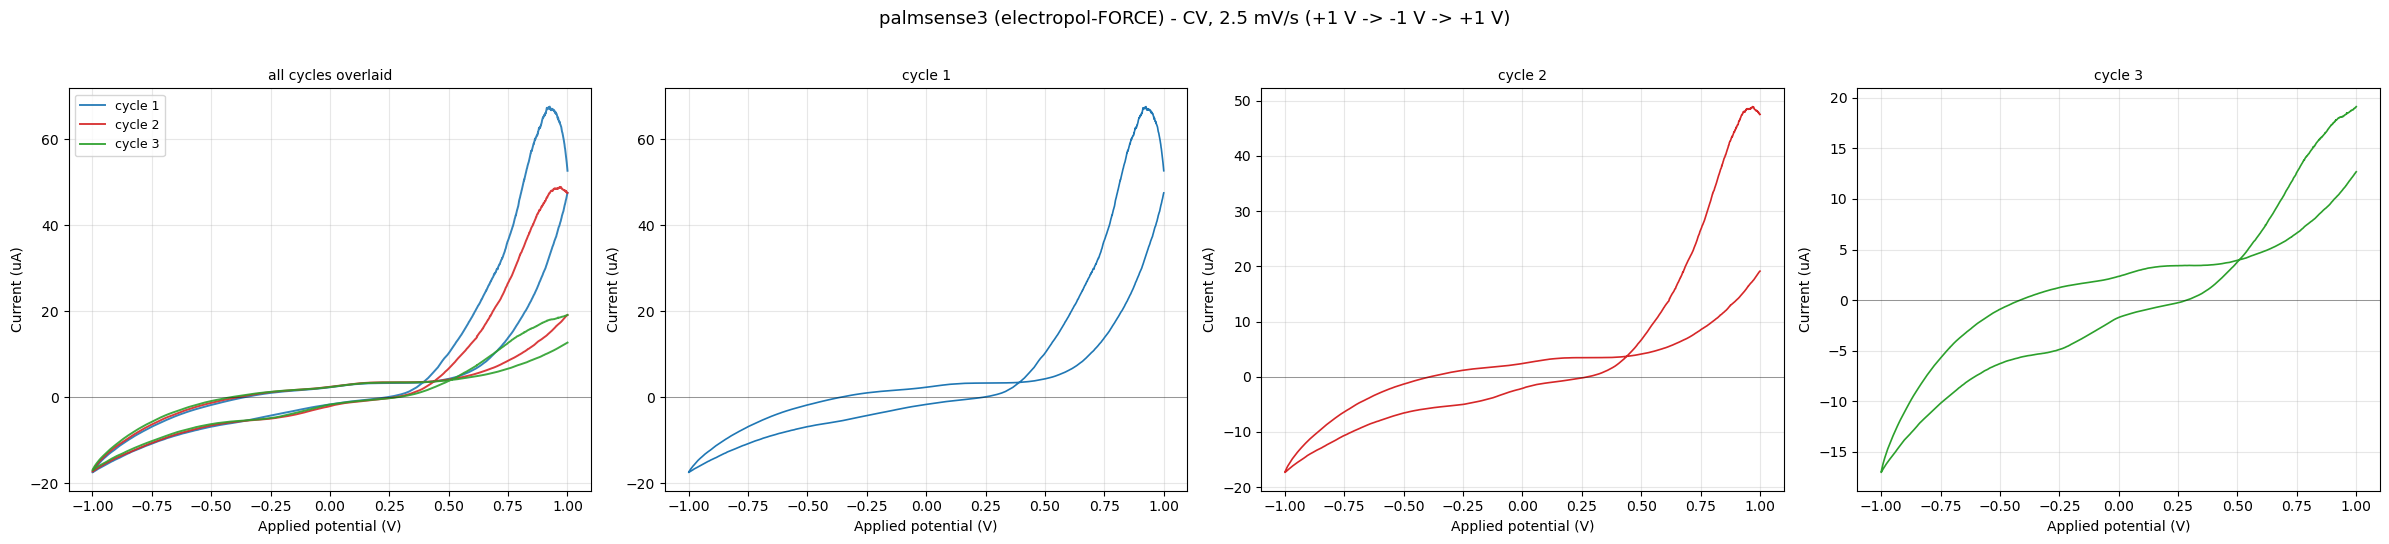

In [8]:
df3, n3 = plot_cv(PALMSENSE3, 'palmsense3 (electropol-FORCE)')

## palmsense4 run

Noted as the weaker run - included for completeness.

palmsense4 (electropol-FORCE): 3 scans, 7490 samples/scan


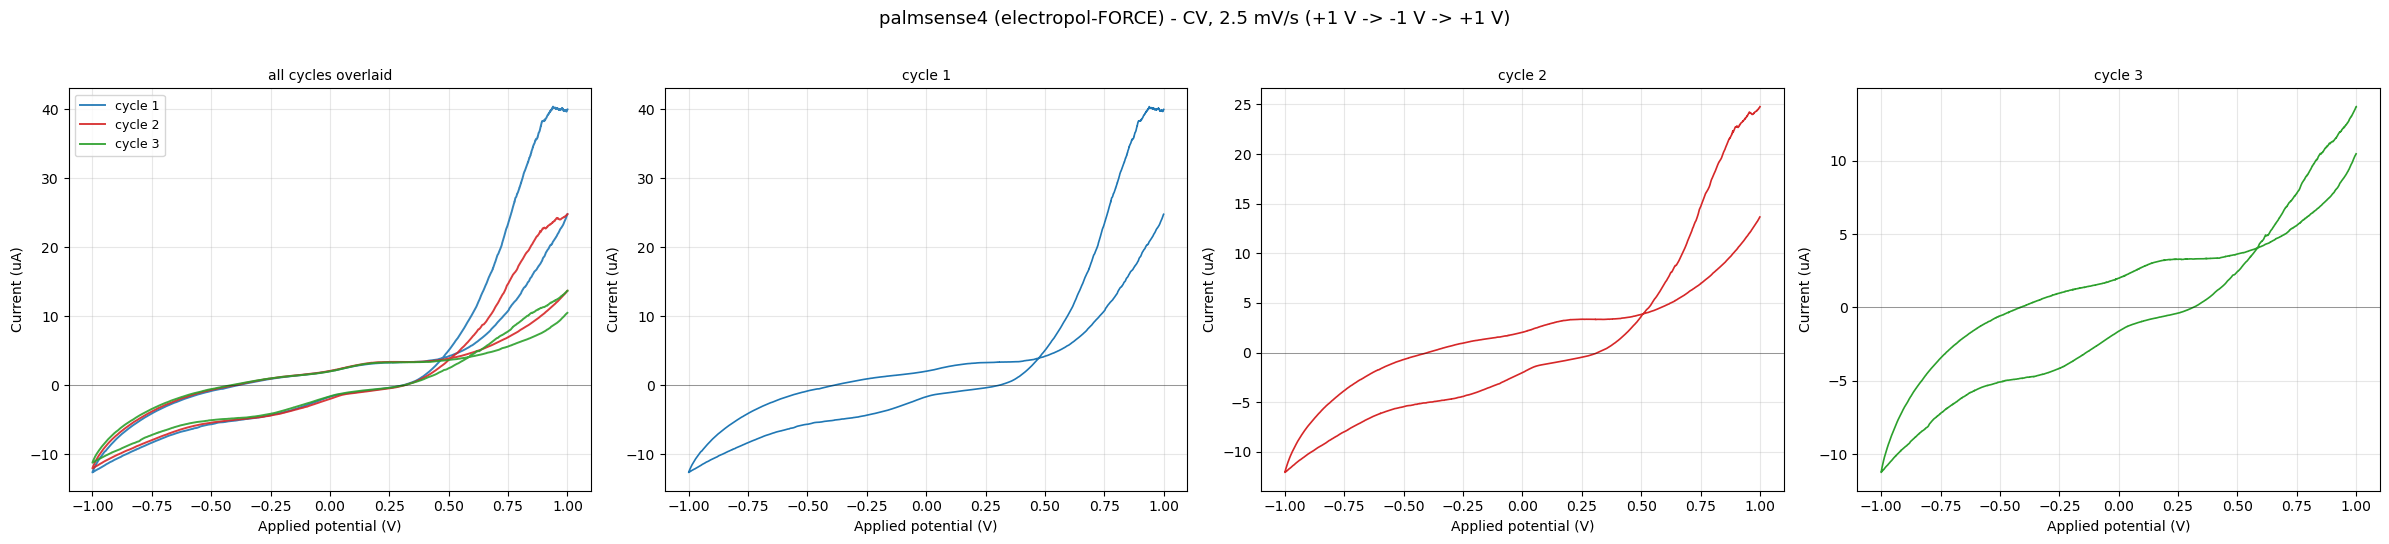

In [9]:
df4, n4 = plot_cv(PALMSENSE4, 'palmsense4 (electropol-FORCE)')

## FORCE scope-log CV (force vs applied potential)

Pairs each scope **force** log (CH2; CH1 is 0) with its potentiostat CV from the same run.
Scope and potentiostat were started together (offset = 0 s); the per-sample interval `DT` is
derived from the recorded voltage step and the 2.5 mV/s scan rate, and each scope sample is
mapped onto the applied potential + cycle index. Same alignment / MAD-outlier-filter /
Savitzky-Golay / per-cycle-creep-removal pipeline as
`6.18.26_misc_experiments/cv_20260618_FORCE_analysis.ipynb`.

Force = CH2 voltage x **56.7 mN/V** (1x gain). Each cycle sweeps +1 V -> -1 V -> +1 V and so
returns to its start; a per-cycle linear-in-time creep is removed so each loop **closes**
(force at end-+1 V == force at start-+1 V). Force is shown as **change relative to each cycle's
+1 V start** so the actuation swings line up at the origin. No stress axis - sample cross-section
for these 500 um tissue runs isn't recorded here.

- palmsense3 scope: `electropol-500um-FORCE-palmsense3_scope_log_20260715_135117.csv`
- palmsense4 scope: `electropol-500um-FORCE-palmsense4-scope_log_20260715_152323.csv`

Heads-up: the raw force swings are small/noisy (palmsense3 ~1 mN, palmsense4 ~12 mN) - these
are the "garbagio" FORCE signals, shown for completeness.

In [10]:
from scipy.signal import savgol_filter

SCAN_RATE_V_PER_S = 0.0025
FORCE_GAIN_MN_PER_V = 56.7          # 1x gain
SCOPE_CHANNEL = 'ch2_MEAN_V'        # force on CH2 (CH1 is 0)
WINDOW, K = 41, 5.0                 # MAD outlier filter
SMOOTH_WINDOW, SAVGOL_POLY, RAW_ALPHA = 101, 3, 0.20

FORCE_RUNS = {
    'palmsense3': (PALMSENSE3, 'electropol-500um-FORCE-palmsense3_scope_log_20260715_135117.csv'),
    'palmsense4': (PALMSENSE4, 'electropol-500um-FORCE-palmsense4-scope_log_20260715_152323.csv'),
}


def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    ad = (s - med).abs()
    mad = ad.rolling(window, center=True, min_periods=1).median()
    mad = mad.clip(lower=max(np.nanstd(x) * 1e-3, 1e-9))
    return (ad > k * mad).values


def savgol_per_cycle(df, col, window=101, poly=3):
    out = pd.Series(np.nan, index=df.index)
    for _, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp'); y = sub[col].values; nn = len(y)
        if nn < 3:
            out.loc[sub.index] = y; continue
        w = min(window, nn); w -= (w % 2 == 0)
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out


def close_loop_per_cycle(df, col, scol):
    # Remove per-cycle linear-in-time drift so each cycle's last smoothed sample == its first.
    out = df[col].astype(float).copy()
    for _, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp'); t = sub['t_exp'].values; y = sub[scol].values
        if len(sub) < 2 or t[-1] == t[0]:
            continue
        slope = (y[-1] - y[0]) / (t[-1] - t[0])
        out.loc[sub.index] = df.loc[sub.index, col].values - slope * (t - t[0])
    return out


def force_cv(poten_path, scope_path, title, show_open=True):
    poten, n = load_poten_cv(poten_path)
    n_per = len(poten)

    v1 = poten['v1'].values
    turn = int(np.argmin(v1))
    DT = abs(v1[0] - v1[turn]) / turn / SCAN_RATE_V_PER_S
    per_scan_s = n_per * DT
    total_s = n * per_scan_s
    t_scan = np.arange(n_per) * DT
    t_full = np.concatenate([t_scan + s * per_scan_s for s in range(n)])
    v_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n)])

    sc = pd.read_csv(scope_path)
    sc['t_exp'] = sc['elapsed_s']
    sc = sc[(sc['t_exp'] >= 0) & (sc['t_exp'] <= total_s)].copy()
    mask = mark_outliers(sc[SCOPE_CHANNEL].values, WINDOW, K)
    sc = sc.loc[~mask].copy()
    sc['v_applied'] = np.interp(sc['t_exp'].values, t_full, v_full)
    sc['cycle'] = np.clip((sc['t_exp'].values // per_scan_s).astype(int), 0, n - 1)

    sc['force_mN'] = sc[SCOPE_CHANNEL] * FORCE_GAIN_MN_PER_V
    sc['smooth'] = savgol_per_cycle(sc, 'force_mN', SMOOTH_WINDOW, SAVGOL_POLY)
    sc['force_closed'] = close_loop_per_cycle(sc, 'force_mN', 'smooth')
    sc['smooth_closed'] = savgol_per_cycle(sc, 'force_closed', SMOOTH_WINDOW, SAVGOL_POLY)

    print(f'{title}: {n} cycles, DT={DT:.3f} s/sample, {per_scan_s:.0f} s/cycle, {len(sc)} clean scope pts')
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5.5), squeeze=False)
    for c in range(n):
        color = PALETTE[c % len(PALETTE)]
        sub = sc[sc['cycle'] == c].sort_values('t_exp')
        if len(sub) < 2:
            continue
        d_open = sub['smooth'].values - sub['smooth'].values[0]
        d_closed = sub['smooth_closed'].values - sub['smooth_closed'].values[0]
        dpp = d_closed.max() - d_closed.min()
        ax = axes[0, c]
        if show_open:
            ax.plot(sub['v_applied'], d_open, color=color, lw=1.2, ls=':', alpha=0.55,
                    label='original (open loop)')
        ax.plot(sub['v_applied'], d_closed, color=color, lw=2.0,
                label='creep-corrected (closed)')
        ax.scatter([sub['v_applied'].values[0], sub['v_applied'].values[-1]],
                   [d_closed[0], d_closed[-1]], color=color, zorder=5, s=40, ec='k', lw=0.5)
        ax.axhline(0, color='k', lw=0.5, alpha=0.5)
        ax.set_xlabel('Applied potential (V)')
        ax.set_ylabel('Delta force from +1 V start (mN)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
        ax.set_title(f'cycle {c+1}  (swing {dpp:.2f} mN)', fontsize=10)
    fig.suptitle(f'{title} - FORCE scope-log CV, 2.5 mV/s (creep-corrected closed loops)', fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return sc, n


### palmsense3 FORCE CV

palmsense3 (electropol-FORCE): 3 cycles, DT=0.184 s/sample, 1600 s/cycle, 9696 clean scope pts


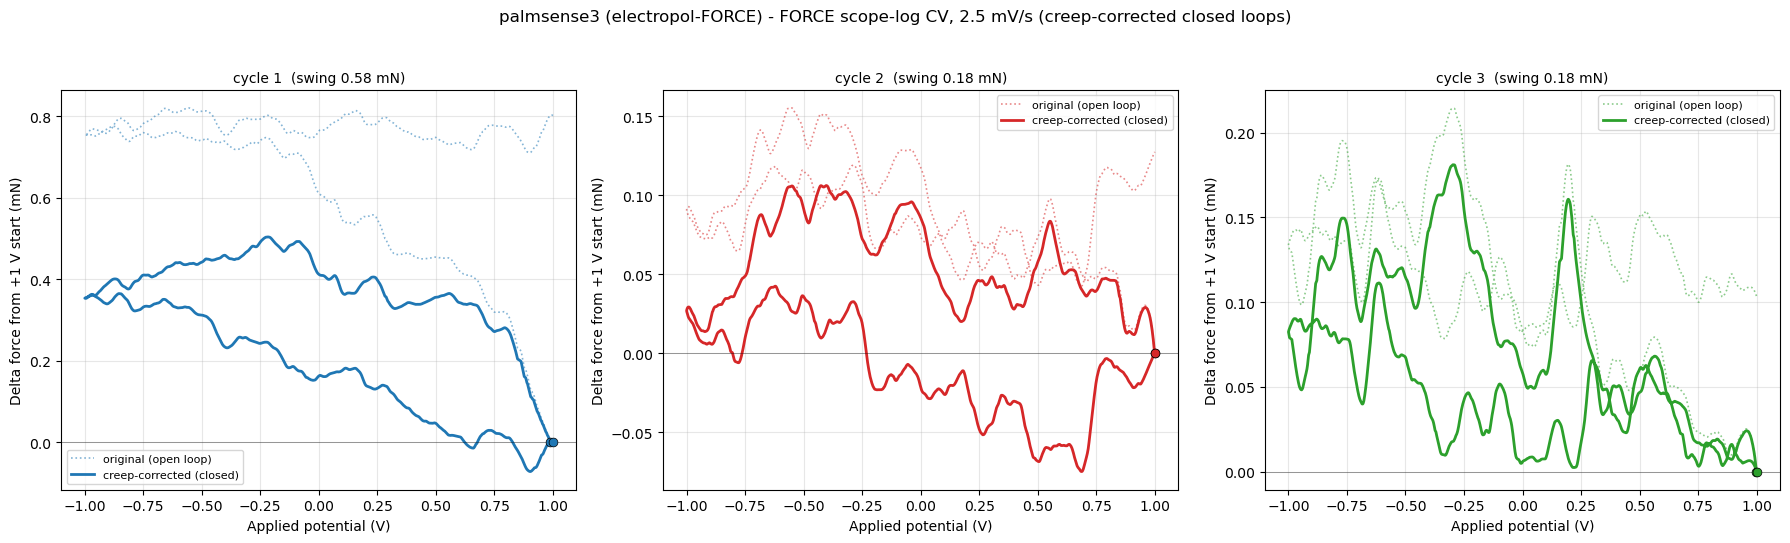

In [11]:
f3, _ = force_cv(*FORCE_RUNS['palmsense3'], 'palmsense3 (electropol-FORCE)')

### palmsense4 FORCE CV

Weaker/noisier run - shown for completeness.

palmsense4 (electropol-FORCE): 3 cycles, DT=0.214 s/sample, 1600 s/cycle, 9626 clean scope pts


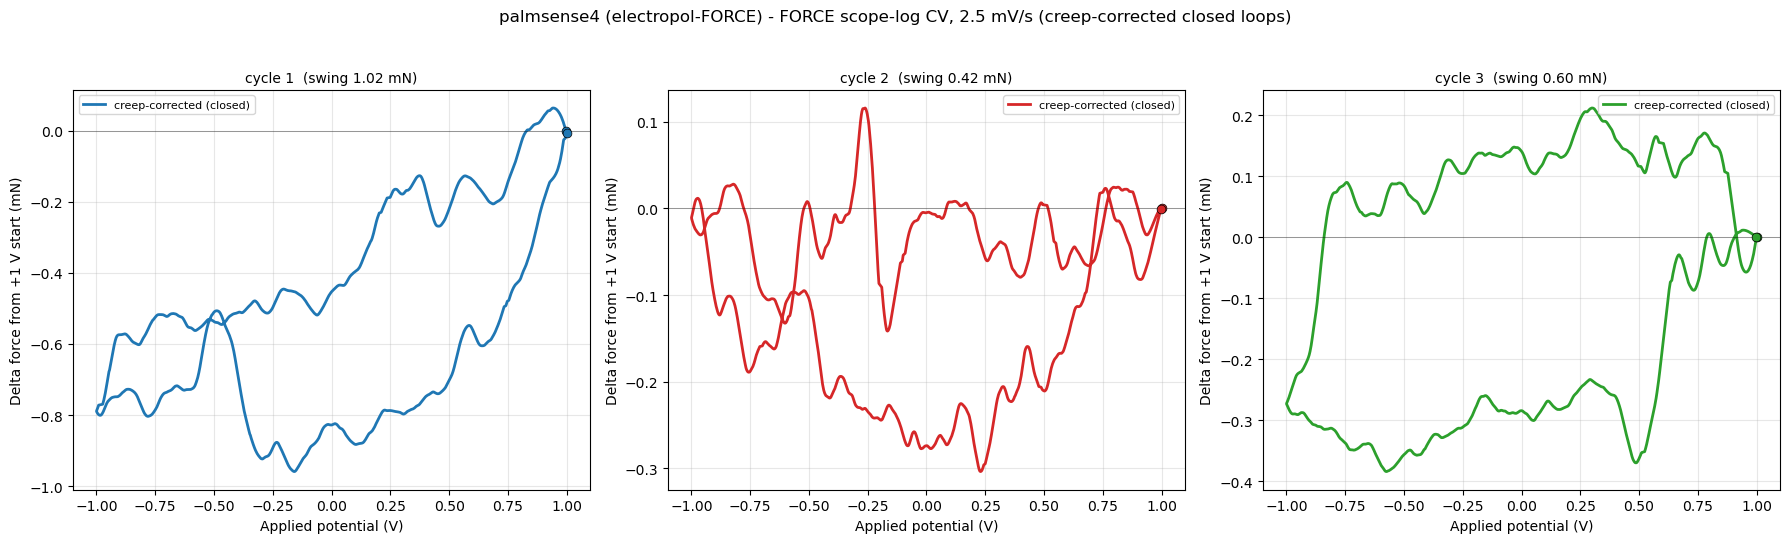

In [12]:
f4, _ = force_cv(*FORCE_RUNS['palmsense4'], 'palmsense4 (electropol-FORCE)', show_open=False)